# NCAR GDEX Capacity-Weighted Wind and Seasonal Allocation Research

This notebook combines the main wind research steps in one reproducible workflow:

1. Use USWTDB turbine capacity and commissioning year to convert GFS 80 m wind into a capacity-weighted theoretical wind-generation shortfall;
2. Preserve the low-wind, rated-output, and extreme-wind shutdown regions through a nonlinear power curve;
3. Remove `sig_observed_weather` and `sig_cpc_level` from direct positioning while keeping both slots fixed at neutral zero rather than reallocating their risk;
4. Separate wind from the legacy weather block and raise its weight independently in March–May and September–October;
5. Select the weight using only the 2016–2020 development period, then report 2021–2023 validation and the post-2024 first-look holdout.

By default the notebook reads existing local Parquet files. It does not download data, upload to GCS, or modify a production factor. Strategy returns switch from the contemporaneous C1 to C2 five trading sessions before expiry.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = next(
    candidate for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / 'naturalgas').is_dir()
)
NG_ROOT = PROJECT_ROOT / 'naturalgas'
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

COMPLETE_ROOT = NG_ROOT / 'processed/ncar_gdex_complete_wind_factor'
AUDIT_ROOT = PROJECT_ROOT / 'inputs/audit/wind'
INDEPENDENT_ROOT = NG_ROOT / 'processed/ncar_gdex_independent_wind_weights'
PANEL_PATH = NG_ROOT / 'processed/ng_multisignal_score/ng_multisignal_panel.parquet'
CAPACITY_FEATURES_PATH = COMPLETE_ROOT / 'capacity_weighted_wind_features_daily.parquet'
ANNUAL_WEIGHTS_PATH = AUDIT_ROOT / 'annual_location_weights.csv'
FLEET_DIAGNOSTICS_PATH = AUDIT_ROOT / 'annual_fleet_diagnostics.csv'

for path in (PANEL_PATH, CAPACITY_FEATURES_PATH, ANNUAL_WEIGHTS_PATH, FLEET_DIAGNOSTICS_PATH):
    assert path.exists(), f'Missing required input: {path}'

pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')
print(f'Project root: {PROJECT_ROOT}')

## 1. Capacity-weighted wind factor

For each GFS issue, apply the power curve at every representative location and valid time before aggregating by installed wind capacity:

$$
EstimatedWindCF_t = \frac{\sum_i Capacity_{i,t}\,PowerCurve(Wind_{i,t})}{\sum_i Capacity_{i,t}}
$$

$$
WindFactor_t = Z^{causal}_{60}(1-EstimatedWindCF_t)
$$

Capacity includes turbines commissioned no later than the year before the forecast issue year. A 0.14 power-law exponent adjusts GFS 80 m wind to hub height. The selected factor equally weights forecast days 1–5; it is not a day-5-only feature.

In [2]:
capacity_features = pd.read_parquet(CAPACITY_FEATURES_PATH)
annual_weights = pd.read_csv(ANNUAL_WEIGHTS_PATH)
fleet = pd.read_csv(FLEET_DIAGNOSTICS_PATH)

primary = (
    capacity_features.loc[capacity_features['forecast_cycle_hour_utc'].eq(0)]
    .sort_values('forecast_reference_time_utc')
    .reset_index(drop=True)
)

summary = pd.Series({
    'all_cycle_rows': len(capacity_features),
    '00z_rows': len(primary),
    'first_00z_issue': primary['date'].min(),
    'last_00z_issue': primary['date'].max(),
    'latest_fleet_capacity_mw': primary['fleet_capacity_mw'].iloc[-1],
    'annual_weight_years': annual_weights['issue_year'].nunique(),
    'proxy_locations': annual_weights['location_id'].nunique(),
})
display(summary.to_frame('value'))
display(primary[[
    'forecast_reference_time_utc', 'fleet_capacity_mw',
    'wind_speed_hub_mps_equal', 'effective_power_cf_equal',
    'total_shortfall_cf_equal', 'sig_capacity_cf'
]].tail(10))

,value
all_cycle_rows,3857
00z_rows,3857
first_00z_issue,2016-01-01 00:00:00
last_00z_issue,2026-07-28 00:00:00
latest_fleet_capacity_mw,"154,442.6400"
annual_weight_years,11
proxy_locations,28


,forecast_reference_time_utc,fleet_capacity_mw,wind_speed_hub_mps_equal,effective_power_cf_equal,total_shortfall_cf_equal,sig_capacity_cf
3847,2026-07-19 00:00:00+00:00,"154,442.6400",5.4862,0.1527,0.8473,0.5386
3848,2026-07-20 00:00:00+00:00,"154,442.6400",5.8244,0.1788,0.8212,0.2477
3849,2026-07-21 00:00:00+00:00,"154,442.6400",6.0586,0.1999,0.8001,0.0166
3850,2026-07-22 00:00:00+00:00,"154,442.6400",6.3508,0.2203,0.7797,-0.2047
3851,2026-07-23 00:00:00+00:00,"154,442.6400",6.1375,0.2000,0.8000,0.0707
3852,2026-07-24 00:00:00+00:00,"154,442.6400",6.0664,0.1878,0.8122,0.2506
3853,2026-07-25 00:00:00+00:00,"154,442.6400",5.9102,0.1844,0.8156,0.3209
3854,2026-07-26 00:00:00+00:00,"154,442.6400",6.2421,0.2151,0.7849,-0.0553
3855,2026-07-27 00:00:00+00:00,"154,442.6400",6.2334,0.2168,0.7832,-0.0506
3856,2026-07-28 00:00:00+00:00,"154,442.6400",6.0691,0.2007,0.7993,0.1879


### Nonlinear power curve

- Below 3 m/s: below cut-in speed, with zero theoretical generation;
- 3–12 m/s: normalized cubic ramp;
- 12–20 m/s: rated output;
- 20–25 m/s: gradual cosine derating;
- At or above 25 m/s: cut-out shutdown.

The output is a theoretical capacity factor, not observed generation. Curtailment, congestion, outages, and availability are not modeled separately.

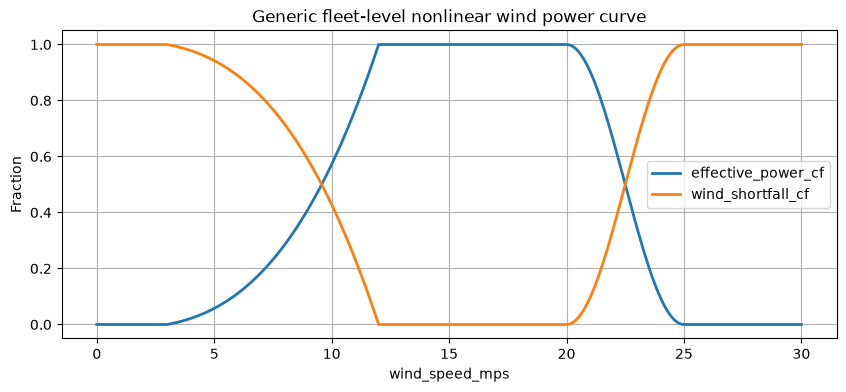

,m/s
cut_in_mps,3.0000
rated_mps,12.0000
high_wind_derate_start_mps,20.0000
cut_out_mps,25.0000


In [3]:
from naturalgas.ncar_gdex_nonlinear_wind import (
    DEFAULT_POWER_CURVE, causal_zscore, nonlinear_power_components,
)

speed = np.linspace(0.0, 30.0, 301)
components = nonlinear_power_components(speed)
curve = pd.DataFrame({
    'wind_speed_mps': speed,
    'effective_power_cf': components['effective_power_cf'],
    'wind_shortfall_cf': components['total_shortfall_cf'],
})

ax = curve.plot(
    x='wind_speed_mps', y=['effective_power_cf', 'wind_shortfall_cf'],
    figsize=(10, 4), lw=2, grid=True,
)
ax.set(title='Generic fleet-level nonlinear wind power curve', ylabel='Fraction')
plt.show()
display(pd.Series(DEFAULT_POWER_CURVE.__dict__, name='m/s').to_frame())

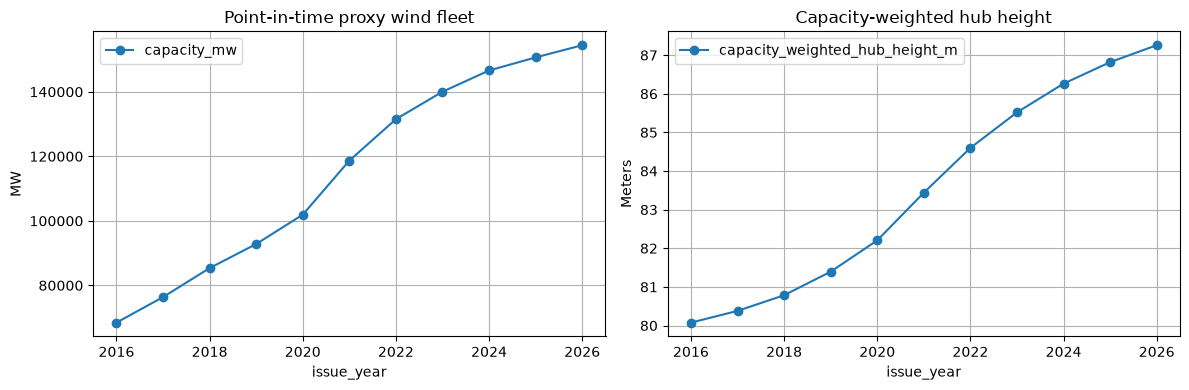

Max signal reproduction difference: 0


In [4]:
# Verify that each signal uses only the preceding 60 issues from the same GFS cycle.
recalculated_signal = capacity_features.groupby(
    'forecast_cycle_hour_utc', group_keys=False
)['total_shortfall_cf_equal'].transform(causal_zscore)
max_signal_difference = (
    recalculated_signal - capacity_features['sig_capacity_cf']
).abs().max()
assert max_signal_difference < 1e-12

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fleet.plot(x='issue_year', y='capacity_mw', marker='o', ax=axes[0], grid=True)
axes[0].set(title='Point-in-time proxy wind fleet', ylabel='MW')
fleet.plot(
    x='issue_year', y='capacity_weighted_hub_height_m',
    marker='o', ax=axes[1], grid=True,
)
axes[1].set(title='Capacity-weighted hub height', ylabel='Meters')
plt.tight_layout()
plt.show()
print(f'Max signal reproduction difference: {max_signal_difference:.3g}')

## 2. Independent shoulder-season wind weight

Wind is no longer mechanically equal-weighted as one item inside a four-factor weather block. It becomes an independent top-level component. `sig_observed_weather` and `sig_cpc_level` no longer enter the position directly; to avoid mechanically increasing the remaining signal after deletion, the original three-slot weather block retains a denominator of three and fixes the two removed slots at zero:

$$
Weather^{direct}_t = \frac{\tanh(CPCRevision_t/2)+0_{level}+0_{observed}}{3}
$$

$$
Score_t = w_W Weather_t + w_{Wind}\tanh(WindFactor_t/2) + w_F Fundamental_t
$$

Peak months are November, December, January, February, June, July, and August; shoulder months are March, April, May, September, and October. Candidates keep the shoulder-season top-level weather weight fixed while gradually transferring fundamental weight to wind. CPC seasonal revision is the only active slot in the weather block. Freeze-off protection and the one-session execution lag remain unchanged. The backtest no longer holds C1 through its last trading day; it switches into the then-current C2 five full sessions before the official last trading day. Any future vendor inventory forecast should be studied in a separate slow supply/demand layer rather than inserted here in advance.

In [5]:
from naturalgas.evaluate_ncar_gdex_independent_wind_weights import (
    build_research_panel, candidate_allocations, common_sample,
    allocation_score, evaluate_allocations, select_development_allocation,
)

EARLY_ROLL_TRADING_DAYS = 5
ACTIVE_DIRECT_WEATHER_COMPONENTS = (
    'sig_cpc_seasonal_revision',
)
LEGACY_WEATHER_SLOT_COUNT = 3


def neutralize_non_directional_weather_slots(frame, allocations):
    """Neutralize CPC level and observed weather, then rebuild positions."""
    result = frame.copy()
    result['legacy_weather_before_neutralization'] = result['legacy_weather']
    result['legacy_weather'] = (
        np.tanh(result[list(ACTIVE_DIRECT_WEATHER_COMPONENTS)] / 2.0)
        .fillna(0.0)
        .sum(axis=1)
        / LEGACY_WEATHER_SLOT_COUNT
    )
    result['sig_cpc_level_direct_slot'] = 0.0
    result['sig_observed_weather_direct_slot'] = 0.0
    for allocation in allocations:
        score_column = f'score_{allocation.name}'
        position_column = f'position_{allocation.name}'
        result[score_column] = allocation_score(result, allocation)
        result[position_column] = (
            result[score_column].shift(1).clip(-1.0, 1.0)
        )
    assert result['sig_cpc_level_direct_slot'].eq(0.0).all()
    assert result['sig_observed_weather_direct_slot'].eq(0.0).all()
    return result


def build_ng_roll_calendar(trading_dates, roll_advance_days=0):
    """Build official and early NG roll dates from trading sessions."""
    idx = (
        pd.DatetimeIndex(pd.to_datetime(trading_dates))
        .dropna().unique().sort_values()
    )
    first_delivery = idx.min().to_period('M') + 1
    last_delivery = idx.max().to_period('M')
    rows = []
    for delivery_month in pd.period_range(first_delivery, last_delivery, freq='M'):
        month_start = delivery_month.to_timestamp()
        prior_trading_dates = idx[idx < month_start]
        required_history = 3 + roll_advance_days
        if len(prior_trading_dates) < required_history:
            continue
        official_ltd = prior_trading_dates[-3]
        roll_trade_date = prior_trading_dates[-required_history]
        following_dates = idx[idx > roll_trade_date]
        if len(following_dates) == 0:
            continue
        rows.append({
            'expired_delivery_month': month_start,
            'official_ltd': official_ltd,
            'roll_trade_date': roll_trade_date,
            'roll_switch_date': following_dates[0],
        })
    return pd.DataFrame(rows).sort_values('roll_switch_date').reset_index(drop=True)

allocations = candidate_allocations()
scored = build_research_panel(PANEL_PATH, CAPACITY_FEATURES_PATH, allocations)
scored = neutralize_non_directional_weather_slots(scored, allocations)
official_roll_calendar = build_ng_roll_calendar(scored['date'])
early_roll_calendar = build_ng_roll_calendar(
    scored['date'], roll_advance_days=EARLY_ROLL_TRADING_DAYS,
)
roll_timing_schedule = official_roll_calendar.merge(
    early_roll_calendar[[
        'expired_delivery_month', 'roll_trade_date', 'roll_switch_date',
    ]].rename(columns={
        'roll_trade_date': 'early_roll_trade_date',
        'roll_switch_date': 'early_roll_switch_date',
    }),
    on='expired_delivery_month', how='inner', validate='one_to_one',
).rename(columns={
    'roll_trade_date': 'last_trade_date',
    'roll_switch_date': 'official_roll_switch_date',
})

calendar_switch_flag = scored['date'].isin(
    roll_timing_schedule['official_roll_switch_date']
)
assert np.array_equal(
    calendar_switch_flag.to_numpy(), scored['is_roll_switch'].to_numpy(),
), 'Rebuilt official calendar differs from the upstream roll flags'

early_c2_window = pd.Series(False, index=scored.index)
for roll in roll_timing_schedule.itertuples(index=False):
    early_c2_window |= (
        scored['date'].ge(roll.early_roll_switch_date)
        & scored['date'].lt(roll.official_roll_switch_date)
    )
assert int(early_c2_window.sum()) == (
    EARLY_ROLL_TRADING_DAYS * len(roll_timing_schedule)
), 'Every completed early-roll interval must contain five C2 sessions'

previous_c1 = scored['c1'].shift(1)
previous_c2 = scored['c2'].shift(1)
official_return_rebuilt = np.where(
    scored['is_roll_switch'],
    scored['c1'] / previous_c2 - 1.0,
    scored['c1'] / previous_c1 - 1.0,
)
assert np.allclose(
    official_return_rebuilt, scored['roll_adjusted_return'], equal_nan=True,
), 'Official LTD return reconstruction differs from the input panel'

scored['official_ltd_roll_return'] = scored['roll_adjusted_return']
scored['early_5d_roll_return'] = np.where(
    early_c2_window, scored['c2'] / previous_c2 - 1.0,
    official_return_rebuilt,
)
scored['early_5d_holds_c2'] = early_c2_window
scored['early_5d_roll_switch'] = scored['date'].isin(
    roll_timing_schedule['early_roll_switch_date']
)
# Downstream research helpers read this standard return column.
scored['roll_adjusted_return'] = scored['early_5d_roll_return']

daily = common_sample(scored, allocations, through_date=pd.Timestamp('2026-07-31'))
comparison, periods = evaluate_allocations(daily, allocations)
selected = select_development_allocation(periods, allocations)

sample_rolls = roll_timing_schedule.loc[
    roll_timing_schedule['official_roll_switch_date'].between(
        daily['date'].min(), daily['date'].max(),
    )
]
print(f'Common sample: {daily.date.min().date()} -> {daily.date.max().date()} | {len(daily):,} sessions')
print(
    f'Early-roll events: {len(sample_rolls):,} | '
    f'C2 return sessions in sample: {int(daily["early_5d_holds_c2"].sum()):,}'
)
display(sample_rolls[[
    'expired_delivery_month', 'early_roll_trade_date',
    'early_roll_switch_date', 'official_ltd', 'official_roll_switch_date',
]].tail(12))
display(pd.Series({
    'sig_cpc_seasonal_revision_slot': 'active (1/3 of weather group)',
    'sig_cpc_level_slot': 'neutral zero (1/3 slot retained)',
    'sig_observed_weather_slot': 'neutral zero (1/3 slot retained)',
}, name='direct-position policy').to_frame())
display(pd.Series(selected.__dict__, name='selected').to_frame())

Common sample: 2016-07-06 -> 2026-07-13 | 2,515 sessions
Early-roll events: 120 | C2 return sessions in sample: 600


,expired_delivery_month,early_roll_trade_date,early_roll_switch_date,official_ltd,official_roll_switch_date
378,2025-08-01,2025-07-22,2025-07-23,2025-07-29,2025-07-30
379,2025-09-01,2025-08-20,2025-08-21,2025-08-27,2025-08-28
380,2025-10-01,2025-09-19,2025-09-22,2025-09-26,2025-09-29
381,2025-11-01,2025-10-22,2025-10-23,2025-10-29,2025-10-30
382,2025-12-01,2025-11-18,2025-11-19,2025-11-25,2025-11-26
383,2026-01-01,2025-12-19,2025-12-22,2025-12-29,2025-12-30
384,2026-02-01,2026-01-21,2026-01-22,2026-01-28,2026-01-29
385,2026-03-01,2026-02-18,2026-02-19,2026-02-25,2026-02-26
386,2026-04-01,2026-03-20,2026-03-23,2026-03-27,2026-03-30
387,2026-05-01,2026-04-21,2026-04-22,2026-04-28,2026-04-29


,direct-position policy
sig_cpc_seasonal_revision_slot,active (1/3 of weather group)
sig_cpc_level_slot,neutral zero (1/3 slot retained)
sig_observed_weather_slot,neutral zero (1/3 slot retained)


,selected
name,independent_shoulder_22p5pct
peak_legacy_weather,0.4500
peak_wind,0.1500
peak_fundamental,0.4000
shoulder_legacy_weather,0.2250
shoulder_wind,0.2250
shoulder_fundamental,0.5500
allocation_source,increase shoulder wind at the expense of funda...
eligible_for_development_selection,True


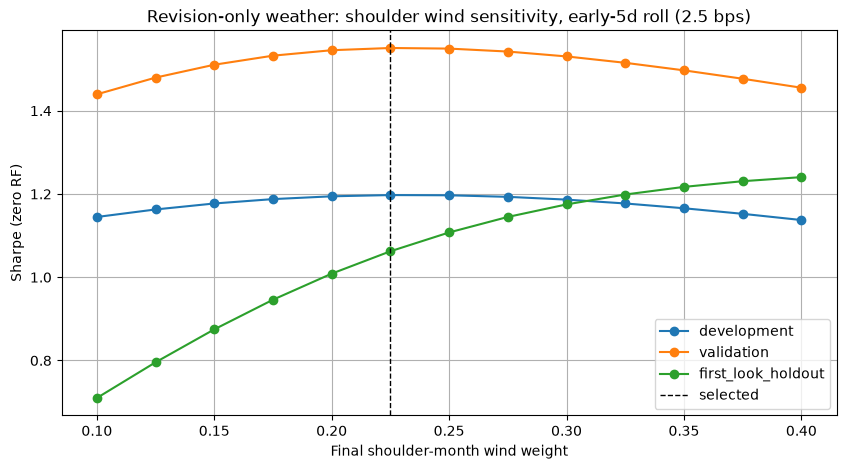

period,development,first_look_holdout,full,validation
shoulder_wind,,,,
0.1000,1.1450,0.7100,1.1280,1.4390
0.1250,1.1630,0.7960,1.1700,1.4800
0.1500,1.1770,0.8750,1.2070,1.5100
0.1750,1.1880,0.9460,1.2360,1.5320
0.2000,1.1940,1.0090,1.2590,1.5450
0.2250,1.1970,1.0620,1.2750,1.5510
0.2500,1.1970,1.1080,1.2860,1.5490
0.2750,1.1930,1.1450,1.2910,1.5420
0.3000,1.1860,1.1750,1.2920,1.5300


In [6]:
candidate_table = pd.DataFrame(item.__dict__ for item in allocations)
sensitivity = (
    periods.merge(
        candidate_table[['name', 'shoulder_wind', 'eligible_for_development_selection']],
        left_on='allocation', right_on='name', how='left',
    )
    .loc[lambda frame: frame['eligible_for_development_selection'].eq(True)]
    .pivot(index='shoulder_wind', columns='period', values='sharpe_zero_rf')
)

ax = sensitivity[['development', 'validation', 'first_look_holdout']].plot(
    figsize=(10, 5), marker='o', grid=True,
)
ax.axvline(selected.shoulder_wind, color='black', ls='--', lw=1, label='selected')
ax.set(
    title='Revision-only weather: shoulder wind sensitivity, early-5d roll (2.5 bps)',
    xlabel='Final shoulder-month wind weight', ylabel='Sharpe (zero RF)',
)
ax.legend()
plt.show()
display(sensitivity.round(3))

In [7]:
key_allocations = [
    'no_wind_original',
    'embedded_shoulder_7p5',
    'independent_shoulder_30pct',
    selected.name,
]
period_view = periods.loc[
    periods['allocation'].isin(key_allocations),
    ['period', 'allocation', 'trading_days', 'cagr',
     'annualized_volatility', 'sharpe_zero_rf',
     'maximum_drawdown', 'total_turnover'],
].copy()
display(period_view.sort_values(['period', 'allocation']))

gross_view = comparison.loc[
    comparison['cost_bps'].eq(0) & comparison['allocation'].isin(key_allocations),
    ['allocation', 'cagr', 'annualized_volatility',
     'sharpe_zero_rf', 'maximum_drawdown', 'total_turnover'],
]
print('Full-sample early-5d-roll results before transaction costs')
display(gross_view)

,period,allocation,trading_days,cagr,annualized_volatility,sharpe_zero_rf,maximum_drawdown,total_turnover
5,development,embedded_shoulder_7p5,1130,0.0699,0.0602,1.1231,-0.0531,58.5443
29,development,independent_shoulder_22p5pct,1130,0.0761,0.0613,1.1974,-0.0539,70.2767
41,development,independent_shoulder_30pct,1130,0.0789,0.0641,1.1864,-0.0555,77.6923
1,development,no_wind_original,1130,0.0431,0.0556,0.7606,-0.0507,55.0170
7,first_look_holdout,embedded_shoulder_7p5,634,0.0419,0.0666,0.6189,-0.0799,31.0883
31,first_look_holdout,independent_shoulder_22p5pct,634,0.0785,0.0714,1.0623,-0.0586,37.3605
43,first_look_holdout,independent_shoulder_30pct,634,0.0967,0.0789,1.1749,-0.0648,41.2879
3,first_look_holdout,no_wind_original,634,0.0352,0.0644,0.5389,-0.0958,26.8635
4,full,embedded_shoulder_7p5,2515,0.0732,0.0657,1.0789,-0.0799,126.9690
28,full,independent_shoulder_22p5pct,2515,0.0924,0.0695,1.2754,-0.0586,152.7190


Full-sample early-5d-roll results before transaction costs


,allocation,cagr,annualized_volatility,sharpe_zero_rf,maximum_drawdown,total_turnover
0,no_wind_original,0.0618,0.0628,0.9594,-0.0957,117.1120
3,embedded_shoulder_7p5,0.0766,0.0657,1.1275,-0.0797,126.9690
21,independent_shoulder_22p5pct,0.0965,0.0695,1.3304,-0.0575,152.7190
30,independent_shoulder_30pct,0.1063,0.0753,1.3480,-0.0637,168.8711


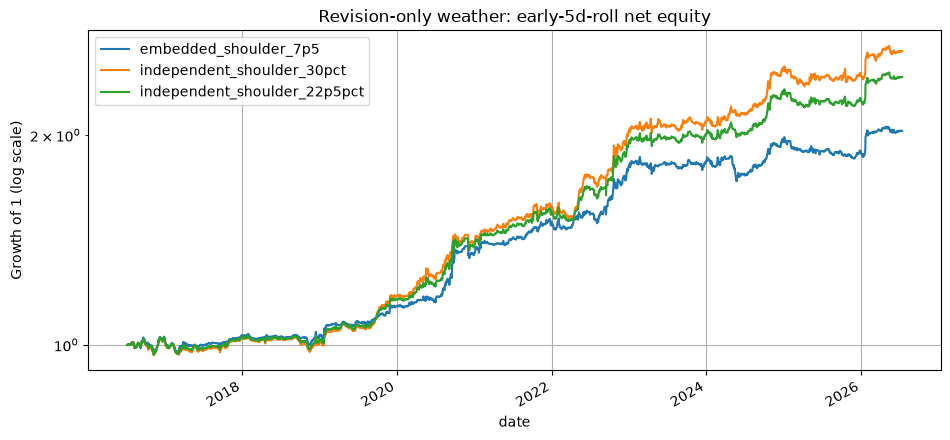

In [8]:
# Use the five-session early-roll return and charge 2.5 bps on position changes.
equity = pd.DataFrame({'date': daily['date']})
for name in ['embedded_shoulder_7p5', 'independent_shoulder_30pct', selected.name]:
    position = daily[f'position_{name}']
    turnover = position.diff().abs().fillna(position.abs())
    net_return = position * daily['roll_adjusted_return'] - turnover * 2.5 / 10_000
    equity[name] = (1.0 + net_return).cumprod()

ax = equity.set_index('date').plot(figsize=(11, 5), logy=True, grid=True)
ax.set(title='Revision-only weather: early-5d-roll net equity', ylabel='Growth of 1 (log scale)')
plt.show()

In [9]:
def annual_sharpe(frame, position_column, cost_bps=2.5):
    position = frame[position_column]
    turnover = position.diff().abs().fillna(position.abs())
    returns = position * frame['roll_adjusted_return'] - turnover * cost_bps / 10_000
    log_return = np.log1p(returns)
    return log_return.mean() / log_return.std() * np.sqrt(252)

annual_rows = []
for year, frame in daily.groupby(daily['date'].dt.year):
    for name in ['embedded_shoulder_7p5', selected.name]:
        annual_rows.append({
            'year': year, 'allocation': name,
            'sharpe': annual_sharpe(frame, f'position_{name}'),
        })
annual = pd.DataFrame(annual_rows).pivot(
    index='year', columns='allocation', values='sharpe'
)
annual['selected_minus_embedded'] = (
    annual[selected.name] - annual['embedded_shoulder_7p5']
)
display(annual.round(3))

allocation,embedded_shoulder_7p5,independent_shoulder_22p5pct,selected_minus_embedded
year,,,
2016,0.6510,0.6080,-0.0420
2017,0.2380,0.1590,-0.0790
2018,0.0230,-0.2230,-0.2450
2019,1.8280,2.3970,0.5680
2020,1.9420,1.9710,0.0290
2021,1.7310,1.6260,-0.1060
2022,2.0500,2.3580,0.3070
2023,0.2210,0.3900,0.1690
2024,1.0360,1.9200,0.8850


## 3. Conclusions and limitations

After setting the direct contributions of `sig_observed_weather` and `sig_cpc_level` to zero, the development-selected research allocation is:

| Period | Nominal weather block | CPC level | Observed weather | Wind | Fundamentals |
|---|---:|---:|---:|---:|---:|
| Peak winter/summer months | 45.0% | **0%** | **0%** | 15.0% | 40.0% |
| Shoulder months | 22.5% | **0%** | **0%** | 22.5% | 55.0% |

The weather block still contains three fixed equal slots: CPC seasonal revision, neutral CPC level, and neutral observed weather. The only active CPC revision can therefore contribute at most 15% in peak months and 7.5% in shoulder months; none of the risk freed by the removed slots is reallocated.

With the five-session early roll and 2.5 bps turnover cost, the 22.5% version has Sharpe ratios of 1.197 in development, 1.551 in validation, 1.062 in the post-2024 first-look holdout, and 1.275 over the full sample; maximum drawdown is -5.86%. Full-sample Sharpe before costs is 1.330. Development performance forms a plateau around 22.5%–25%, with 22.5% having the highest unrounded development Sharpe. Validation is also strongest near 22.5%, while holdout Sharpe continues to rise across the tested range; neither later period participates in selection.

Relative to the prior version that removed only observed weather, setting CPC level to zero raises full-sample Sharpe from 1.110 to 1.275 and improves maximum drawdown from -8.85% to -5.86%, while net CAGR slips from 9.41% to 9.24%. The benefit comes from lower volatility and drawdown rather than higher absolute return. Annual effects are uneven: 2018 Sharpe improves from -0.474 to -0.223 and 2023 from 0.061 to 0.390, while 2025 declines slightly from -0.502 to -0.527. The evidence supports excluding CPC level from fast directional positioning, but removal does not improve every year.

Future vendor data should first support a separate inventory-change or supply/demand forecast and then be tested for incremental value. Cumulative realized weather or an unadjusted CPC absolute level should not be inserted directly into the position.

Principal limitations:

- Historical USWTDB capacity is reconstructed from the current database snapshot and commissioning years, not archived vintages;
- The generic power curve does not distinguish turbine models;
- Curtailment, transmission congestion, wake losses, and unit availability are not explicitly modeled;
- The post-2024 period is called a first-look holdout, but the broader research program has viewed the full sample and it is not pristine out-of-sample evidence;
- The decision to remove CPC level used post-2021 diagnostics, so later-period performance is diagnostic rather than clean holdout evidence;
- The 2.5 bps charge applies to position changes and does not separately charge both legs of a mechanical monthly contract roll;
- Returns hold the contemporaneous C2 during the five full sessions before the official last trading day and continue with the same contract after it becomes the new C1; the model does not hold the expiring C1 to maturity.